# Module 2: MLP + Backpropagation


Prerequisite: the Perceptron failed on XOR in `01_perceptron.ipynb`. Now we'll build a 2-layer MLP from scratch in NumPy and watch it solve the same problem.

**What's in this notebook:**
1. Define a 2-2-1 MLP with sigmoid activations.
2. Implement the forward pass.
3. Implement the backward pass (chain rule, by hand).
4. Train on XOR and watch the loss drop.
5. Plot the curved decision boundary.
6. Compare with a ~10-line

**TensorFlow / Keras** version that does the same thing in production style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print('numpy', np.__version__)


numpy 2.0.2


## 9. The MLP ->  from scratch

Architecture: 2 inputs → 2 hidden neurons (sigmoid) → 1 output (sigmoid).

We'll use the squared-error loss `L = (y − ŷ)²` to keep the math simple. Cross-entropy is more standard for classification (Module 4) but the gradients are messier; with sigmoid + MSE the demonstrative value is the same.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_deriv_from_output(s):
    # If s = sigmoid(z), then dsigmoid/dz = s · (1 − s).
    return s * (1.0 - s)


class TinyMLP:
    """2 → 2 → 1 MLP with sigmoid activations, MSE loss, plain SGD."""

    def __init__(self, lr=0.5, seed=0):
        rng = np.random.default_rng(seed)
        # Small random initialization (we'll discuss why in Module 6).
        self.W1 = rng.normal(0, 1, size=(2, 2))   # input → hidden
        self.b1 = np.zeros(2)
        self.W2 = rng.normal(0, 1, size=(2,))     # hidden → output (1 neuron)
        self.b2 = 0.0
        self.lr = lr

    # ---- forward pass ----
    def forward(self, x):
        # x: shape (2,)
        self.x  = x
        self.z1 = self.W1 @ x + self.b1            # pre-activation, hidden
        self.h  = sigmoid(self.z1)                 # activation, hidden
        self.z2 = self.W2 @ self.h + self.b2       # pre-activation, output
        self.y_hat = sigmoid(self.z2)              # final prediction
        return self.y_hat

    # ---- backward pass: chain rule, by hand ----
    def backward(self, y):
        # Loss L = (y - y_hat)^2
        # dL/dy_hat = -2 (y - y_hat)
        dL_dyhat = -2.0 * (y - self.y_hat)
        # dy_hat/dz2 = sigmoid'(z2) = y_hat*(1-y_hat)
        dyhat_dz2 = sigmoid_deriv_from_output(self.y_hat)
        dL_dz2 = dL_dyhat * dyhat_dz2

        # Gradient for W2 (vector of length 2): dz2/dW2 = h
        dL_dW2 = dL_dz2 * self.h
        dL_db2 = dL_dz2

        # Backprop into hidden layer: dL/dh = dL/dz2 · W2
        dL_dh = dL_dz2 * self.W2
        # dh/dz1 = sigmoid'(z1) = h*(1-h)
        dh_dz1 = sigmoid_deriv_from_output(self.h)
        dL_dz1 = dL_dh * dh_dz1

        # Gradient for W1 (matrix 2x2): dz1/dW1[i,j] = x[j] when row i, else 0
        dL_dW1 = np.outer(dL_dz1, self.x)
        dL_db1 = dL_dz1

        return dL_dW1, dL_db1, dL_dW2, dL_db2

    def update(self, grads):
        gW1, gb1, gW2, gb2 = grads
        self.W1 -= self.lr * gW1
        self.b1 -= self.lr * gb1
        self.W2 -= self.lr * gW2
        self.b2 -= self.lr * gb2

    # ---- convenience ----
    def predict(self, X):
        return np.array([self.forward(x) for x in X])

    def loss(self, X, y):
        preds = self.predict(X)
        return float(np.mean((y - preds) ** 2))


print('TinyMLP class defined.')

# Network Architecture Description:
# The TinyMLP is a feedforward neural network with a 2-2-1 architecture:
# - Input Layer: 2 input features (corresponding to 'x').
# - Hidden Layer: 2 neurons, each with a sigmoid activation function.
#   - These neurons compute 'h = sigmoid(W1 @ x + b1)'.
# - Output Layer: 1 neuron, also with a sigmoid activation function.
#   - This neuron computes 'y_hat = sigmoid(W2 @ h + b2)'.
#
# Conceptual Diagram:
# Input 1 -----|      |---- Hidden Neuron 1 ----|
#              |  W1  |                        |  W2  |---- Output
# Input 2 -----|      |---- Hidden Neuron 2 ----|
#    (x)        (b1)       (h)                (b2)     (y_hat)
#
# Each line represents a connection with an associated weight (part of W1 or W2).
# Each 'node' (Hidden Neuron 1, Hidden Neuron 2, Output) has an associated bias (b1 or b2).


TinyMLP class defined.


## 10. Train the MLP on XOR

Loop for several thousand steps. Each step:

1. Pick one of the 4 XOR samples.
2. Forward — compute `y_hat`.
3. Backward — compute gradients with the chain rule.
4. Update — nudge weights to reduce the loss.

Watch the loss fall. The perceptron in Section 5 oscillated forever; this MLP **converges**.

In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

mlp = TinyMLP(lr=0.5, seed=1)
loss_history = []
EPOCHS = 5000

for epoch in range(EPOCHS):
    for xi, yi in zip(X_xor, y_xor):
        mlp.forward(xi)
        grads = mlp.backward(yi)
        mlp.update(grads)
    if epoch % 500 == 0 or epoch == EPOCHS - 1:
        loss_history.append((epoch, mlp.loss(X_xor, y_xor)))

print('Epoch  |  Loss')
print('-' * 22)
for ep, l in loss_history:
    print(f'{ep:5d}  |  {l:.4f}')

print()
print('Final predictions vs targets:')
for xi, yi in zip(X_xor, y_xor):
    pred = mlp.forward(xi)
    rounded = int(pred >= 0.5)
    mark = '✓' if rounded == int(yi) else '✗'
    print(f'  input {xi}  target {int(yi)}  predicted {pred:.3f}  → {rounded} {mark}')

acc = np.mean([(mlp.forward(xi) >= 0.5) == bool(yi) for xi, yi in zip(X_xor, y_xor)])
print(f'\nAccuracy: {acc:.2f}')

Epoch  |  Loss
----------------------
    0  |  0.2660
  500  |  0.0148
 1000  |  0.0025
 1500  |  0.0013
 2000  |  0.0009
 2500  |  0.0007
 3000  |  0.0005
 3500  |  0.0004
 4000  |  0.0004
 4500  |  0.0003
 4999  |  0.0003

Final predictions vs targets:
  input [0. 0.]  target 0  predicted 0.019  → 0 ✓
  input [0. 1.]  target 1  predicted 0.984  → 1 ✓
  input [1. 0.]  target 1  predicted 0.984  → 1 ✓
  input [1. 1.]  target 0  predicted 0.017  → 0 ✓

Accuracy: 1.00


## 11. Visualize the curved decision boundary

Plot the MLP's prediction over the entire `[0,1] × [0,1]` square. Unlike the perceptron's straight line, this boundary will *curve*.

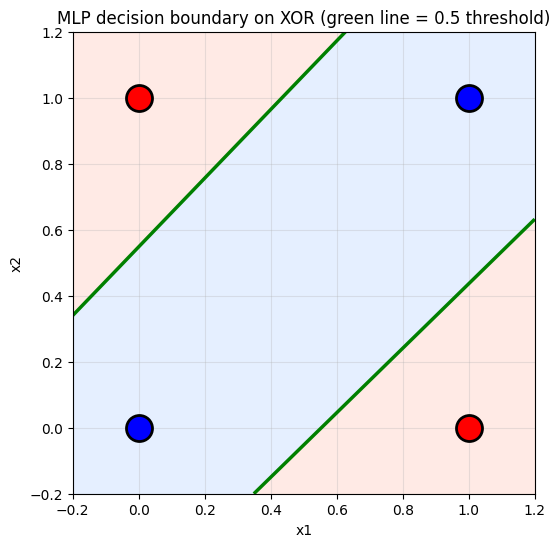

In [5]:
def plot_mlp_boundary(model, X, y):
    fig, ax = plt.subplots(figsize=(7, 6))
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = np.array([model.forward(p) for p in grid]).reshape(xx.shape)
    ax.contourf(xx, yy, preds, levels=[0, 0.5, 1.0],
                colors=['#cce0ff', '#ffd6cc'], alpha=0.5)
    ax.contour(xx, yy, preds, levels=[0.5], colors='green', linewidths=2.5)
    for xi, yi in zip(X, y):
        c = 'red' if yi == 1 else 'blue'
        ax.scatter(xi[0], xi[1], c=c, s=350, edgecolors='black',
                   linewidths=2, zorder=10)
    ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title('MLP decision boundary on XOR (green line = 0.5 threshold)')
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')
    plt.show()


plot_mlp_boundary(mlp, X_xor, y_xor)

## 12. What did the hidden neurons learn?

Print each hidden neuron's output for all 4 XOR inputs. You'll see that one neuron tends to act like an OR (or AND) and the other like its complement, together they let the output combine them into XOR.

Each hidden neuron carves the input space with its own straight line. Two lines + non-linearity = a curved region. This is feature learning in miniature.

In [6]:
print('  input    h1     h2    -> y_hat')
print('-' * 40)
for xi, yi in zip(X_xor, y_xor):
    mlp.forward(xi)
    print(f'  {xi}  {mlp.h[0]:.3f}  {mlp.h[1]:.3f}    {mlp.y_hat:.3f}   (target {int(yi)})')

print()
print('Final learned weights:')
print('  W1 =', mlp.W1)
print('  b1 =', mlp.b1)
print('  W2 =', mlp.W2)
print('  b2 =', mlp.b2)

  input    h1     h2    -> y_hat
----------------------------------------
  [0. 0.]  0.041  0.031    0.019   (target 0)
  [0. 1.]  0.926  0.000    0.984   (target 1)
  [1. 0.]  0.000  0.940    0.984   (target 1)
  [1. 1.]  0.033  0.027    0.017   (target 0)

Final learned weights:
  W1 = [[-5.89873487  5.67206759]
 [ 6.19804254 -6.33977351]]
  b1 = [-3.15126861 -3.44477004]
  W2 = [9.44567103 9.30894205]
  b2 = -4.635410896828291


## 12b. Backend view — what did the hidden neurons *actually* compute?

Section 12 printed `h₁` and `h₂` as 4 numbers. Now visualise them across the **entire** input plane so you can *see* the learned feature space.

For every `(x₁, x₂)` on a fine grid we evaluate `h₁ = σ(w₁₁·x₁ + w₁₂·x₂ + b₁)` and `h₂ = σ(w₂₁·x₁ + w₂₂·x₂ + b₂)`. Each hidden neuron becomes its own heatmap — each cell shows the activation strength at that input.

Then the third panel plots the 4 XOR points **in the (h₁, h₂) hidden-feature plane** and shows that the MLP has warped the input space into a feature space where **XOR becomes linearly separable**. That's the geometric meaning of "non-linear feature learning."

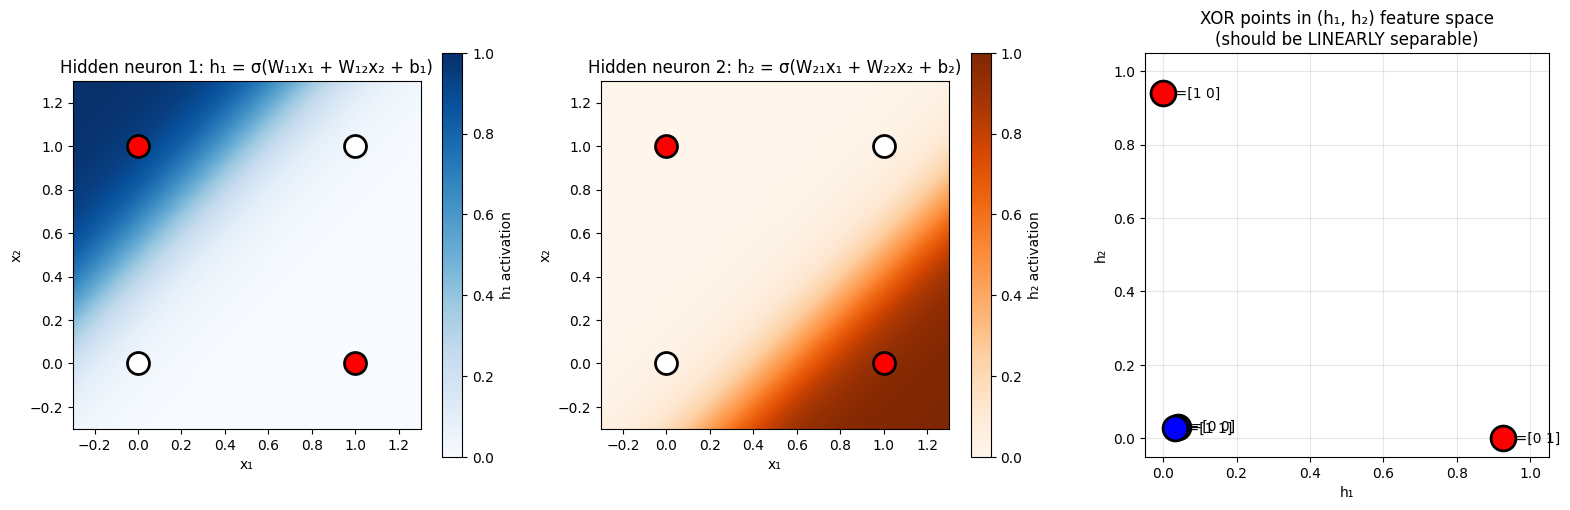


Interpretation:
  • Left/middle panels show each hidden neuron carving input-space with a SIGMOID-SOFTENED line.
  • Right panel shows the 4 XOR points in the (h₁, h₂) plane — the BLUE class (target 0)
    and RED class (target 1) are now separable by a single straight line.
  • The output neuron then draws that straight line — that's how a 2-2-1 MLP solves XOR.

THIS is what "non-linear feature learning" means: the network warps input space into a
NEW space where the original problem becomes easy. Every deep network is doing this.


In [7]:
# === Build the heatmaps + warped-space scatter ===
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
H1 = np.zeros_like(xx)
H2 = np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        x_pt = np.array([xx[i, j], yy[i, j]])
        mlp.forward(x_pt)
        H1[i, j] = mlp.h[0]
        H2[i, j] = mlp.h[1]

# Hidden-space coordinates of the 4 XOR points
hidden_coords = []
for xi in X_xor:
    mlp.forward(xi)
    hidden_coords.append(mlp.h.copy())
hidden_coords = np.array(hidden_coords)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# === Panel 1: h1 heatmap over input space ===
ax = axes[0]
im = ax.imshow(H1, extent=(-0.3, 1.3, -0.3, 1.3), origin='lower',
               cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='h₁ activation')
for xi, yi in zip(X_xor, y_xor):
    ax.scatter(xi[0], xi[1], c='red' if yi == 1 else 'white',
               s=250, edgecolors='black', linewidths=2, zorder=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Hidden neuron 1: h₁ = σ(W₁₁x₁ + W₁₂x₂ + b₁)')

# === Panel 2: h2 heatmap over input space ===
ax = axes[1]
im = ax.imshow(H2, extent=(-0.3, 1.3, -0.3, 1.3), origin='lower',
               cmap='Oranges', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='h₂ activation')
for xi, yi in zip(X_xor, y_xor):
    ax.scatter(xi[0], xi[1], c='red' if yi == 1 else 'white',
               s=250, edgecolors='black', linewidths=2, zorder=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Hidden neuron 2: h₂ = σ(W₂₁x₁ + W₂₂x₂ + b₂)')

# === Panel 3: warped (h1, h2) space — XOR is linearly separable here ===
ax = axes[2]
for (h1v, h2v), yi, xi in zip(hidden_coords, y_xor, X_xor):
    ax.scatter(h1v, h2v, c='red' if yi == 1 else 'blue',
               s=320, edgecolors='black', linewidths=2, zorder=10)
    ax.annotate(f' x={xi.astype(int)}', (h1v, h2v), fontsize=10, va='center')
ax.set_xlabel('h₁'); ax.set_ylabel('h₂')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_title('XOR points in (h₁, h₂) feature space\n(should be LINEARLY separable)')
ax.grid(alpha=0.3); ax.set_aspect('equal')

plt.tight_layout(); plt.show()

print()
print('Interpretation:')
print('  • Left/middle panels show each hidden neuron carving input-space with a SIGMOID-SOFTENED line.')
print('  • Right panel shows the 4 XOR points in the (h₁, h₂) plane — the BLUE class (target 0)')
print('    and RED class (target 1) are now separable by a single straight line.')
print('  • The output neuron then draws that straight line — that\'s how a 2-2-1 MLP solves XOR.')
print()
print('THIS is what "non-linear feature learning" means: the network warps input space into a')
print('NEW space where the original problem becomes easy. Every deep network is doing this.')

## 12c. Backend view — the loss landscape the optimizer walks on

The MLP has 9 trainable parameters (4 in W₁, 2 in b₁, 2 in W₂, 1 in b₂). We can't visualise a 9D loss surface — but we *can* **freeze 7 parameters at their trained values and sweep the other 2**. The result is a 2D slice of the full loss landscape, which you can render as a contour map.

Below we sweep `W₂[0]` and `W₂[1]` (the output-layer weights) across a wide range and compute the XOR loss at each combination, with all other parameters frozen at their trained values. The **green X** marks where the trained model sits — at a minimum of this slice.

You'll see why optimizers matter: there's a clear "valley" the optimizer needs to descend, and depending on where the random init drops you, gradient descent might or might not find the global minimum. (Modules 5 + 6 are about doing this reliably.)

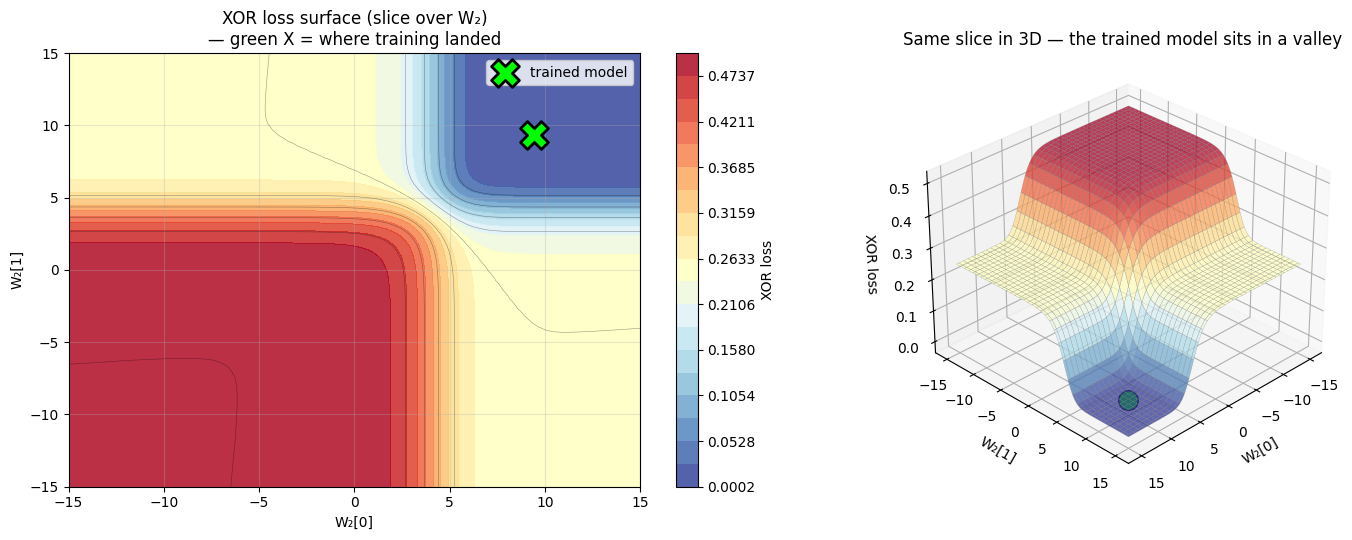


Reading the contour: the dark-red ridges are HIGH loss regions where the output is
confidently WRONG on most XOR inputs. The blue valley is where W₂ correctly weights
the hidden features to produce XOR.

The green X is the spot the optimizer descended to over 5,000 epochs. From a bad
random init it would have needed many gradient updates to get there.

This is a 2D slice of a 9D loss surface. The full landscape is much more complex —
but every 2D slice has the same character: ridges, valleys, sometimes saddles.
Modules 5 (Optimizers) and 6 (Init) are about navigating this efficiently.


In [8]:
# Freeze 7 of 9 params at trained values; sweep W2[0], W2[1]
W1_fix = mlp.W1.copy(); b1_fix = mlp.b1.copy()
b2_fix = mlp.b2

def loss_at(w2_0, w2_1):
    W2_test = np.array([w2_0, w2_1])
    total = 0.0
    for xi, yi in zip(X_xor, y_xor):
        h = sigmoid(W1_fix @ xi + b1_fix)
        y_hat = sigmoid(W2_test @ h + b2_fix)
        total += (yi - y_hat) ** 2
    return total / 4.0

# Sweep grid
grid_size = 80
w0_range = np.linspace(-15, 15, grid_size)
w1_range = np.linspace(-15, 15, grid_size)
W0, W1 = np.meshgrid(w0_range, w1_range)
L = np.array([[loss_at(w0, w1) for w0 in w0_range] for w1 in w1_range])

trained_w2 = mlp.W2

fig = plt.figure(figsize=(15, 5.5))

# === Left: 2D contour ===
ax1 = fig.add_subplot(1, 2, 1)
levels = np.linspace(L.min(), L.max(), 20)
cs = ax1.contourf(W0, W1, L, levels=levels, cmap='RdYlBu_r', alpha=0.85)
ax1.contour(W0, W1, L, levels=10, colors='black', linewidths=0.4, alpha=0.4)
plt.colorbar(cs, ax=ax1, label='XOR loss')
ax1.scatter(trained_w2[0], trained_w2[1], s=400, marker='X', color='lime',
            edgecolors='black', linewidths=2, zorder=5, label='trained model')
ax1.set_xlabel('W₂[0]'); ax1.set_ylabel('W₂[1]')
ax1.set_title('XOR loss surface (slice over W₂)\n— green X = where training landed')
ax1.legend(); ax1.grid(alpha=0.3)

# === Right: 3D wireframe ===
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W0, W1, L, cmap='RdYlBu_r', alpha=0.75,
                 rstride=2, cstride=2, edgecolor='gray', linewidth=0.2)
ax2.scatter(trained_w2[0], trained_w2[1],
            loss_at(trained_w2[0], trained_w2[1]),
            s=200, color='lime', edgecolor='black', zorder=10)
ax2.set_xlabel('W₂[0]'); ax2.set_ylabel('W₂[1]'); ax2.set_zlabel('XOR loss')
ax2.set_title('Same slice in 3D — the trained model sits in a valley')
ax2.view_init(elev=30, azim=45)

plt.tight_layout(); plt.show()

print()
print('Reading the contour: the dark-red ridges are HIGH loss regions where the output is')
print('confidently WRONG on most XOR inputs. The blue valley is where W₂ correctly weights')
print('the hidden features to produce XOR.')
print()
print('The green X is the spot the optimizer descended to over 5,000 epochs. From a bad')
print('random init it would have needed many gradient updates to get there.')
print()
print('This is a 2D slice of a 9D loss surface. The full landscape is much more complex —')
print('but every 2D slice has the same character: ridges, valleys, sometimes saddles.')
print('Modules 5 (Optimizers) and 6 (Init) are about navigating this efficiently.')

## 13. The TensorFlow / Keras version

In real projects we don't write backprop by hand ->`model.fit()` (or `tf.GradientTape` + `optimizer.apply_gradients` for custom training loops) does it for you.

This cell uses Keras's autograd. The math underneath is **exactly** what we did by hand in Section 9–10 -> same architecture (2 → 2 sigmoid → 1 sigmoid), same MSE loss, same SGD step. Skip if TensorFlow isn't installed; the from-scratch version above is the teaching version.

In [9]:
try:
    import tensorflow as tf

    tf.random.set_seed(0)

    # Same architecture as the from-scratch MLP: 2 → 2 (sigmoid) → 1 (sigmoid)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(2, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
        loss='mse',
    )

    X = tf.constant(X_xor,                  dtype=tf.float32)
    y = tf.constant(y_xor.reshape(-1, 1),   dtype=tf.float32)

    # batch_size=4 = full-batch, matches the from-scratch loop above
    history = model.fit(X, y, epochs=5000, batch_size=4, verbose=0)

    print(f'Final loss: {history.history["loss"][-1]:.4f}')
    preds = model.predict(X, verbose=0).flatten()
    for xi, yi, p in zip(X_xor, y_xor, preds):
        print(f'  input {xi}  target {int(yi)}  predicted {p:.3f}')
except ImportError:
    print('TensorFlow not installed in this kernel')
    print('Install with: pip install tensorflow')

Final loss: 0.0028
  input [0. 0.]  target 0  predicted 0.054
  input [0. 1.]  target 1  predicted 0.940
  input [1. 0.]  target 1  predicted 0.949
  input [1. 1.]  target 0  predicted 0.047


In [10]:
try:
    import tensorflow as tf

    tf.random.set_seed(0)

    # Same architecture as the from-scratch MLP: 2 → 2 (sigmoid) → 1 (sigmoid)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(2, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=5.0),
        loss='mse',
    )

    X = tf.constant(X_xor,                  dtype=tf.float32)
    y = tf.constant(y_xor.reshape(-1, 1),   dtype=tf.float32)

    # batch_size=4 = full-batch, matches the from-scratch loop above
    history = model.fit(X, y, epochs=5000, batch_size=4, verbose=0)

    print(f'Final loss: {history.history["loss"][-1]:.4f}')
    preds = model.predict(X, verbose=0).flatten()
    for xi, yi, p in zip(X_xor, y_xor, preds):
        print(f'  input {xi}  target {int(yi)}  predicted {p:.3f}')
except ImportError:
    print('TensorFlow not installed in this kernel')
    print('Install with: pip install tensorflow')

Final loss: 0.0001
  input [0. 0.]  target 0  predicted 0.009
  input [0. 1.]  target 1  predicted 0.990
  input [1. 0.]  target 1  predicted 0.990
  input [1. 1.]  target 0  predicted 0.012


In [11]:
try:
    import tensorflow as tf

    tf.random.set_seed(0)

    # Same architecture as the from-scratch MLP: 2 → 2 (sigmoid) → 1 (sigmoid)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(2, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
        loss='mse',
    )

    X = tf.constant(X_xor,                  dtype=tf.float32)
    y = tf.constant(y_xor.reshape(-1, 1),   dtype=tf.float32)

    # batch_size=4 = full-batch, matches the from-scratch loop above
    history = model.fit(X, y, epochs=5000, batch_size=4, verbose=1)

    print(f'Final loss: {history.history["loss"][-1]:.4f}')
    preds = model.predict(X, verbose=1).flatten()
    for xi, yi, p in zip(X_xor, y_xor, preds):
        print(f'  input {xi}  target {int(yi)}  predicted {p:.3f}')
except ImportError:
    print('TensorFlow not installed in this kernel')
    print('Install with: pip install tensorflow')

Streaming output truncated to the last 5000 lines.
Epoch 2504/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.2805
Epoch 2505/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2805
Epoch 2506/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.2805
Epoch 2507/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2805
Epoch 2508/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.2805
Epoch 2509/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.2805
Epoch 2510/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2805
Epoch 2511/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.2805
Epoch 2512/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2805
Epoch 2513/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.2805
Epoch 2514/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.2805
Epoch 2515/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2805
Epoch 2516/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.2805
Epoch 2517/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141